# 02 SQL in R Analytics
This notebook demonstrates SQL queries inside R using sqldf. It loads the same NorthStar CSV data and produces query outputs required for the SQL in R marking section.

In [1]:
install.packages(c("sqldf", "dplyr", "ggplot2", "readr"), repos="https://cloud.r-project.org")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’




In [3]:
library(sqldf)
library(dplyr)
library(ggplot2)
library(readr)
DATA_DIR <- "/content/northstar_dataset"
if (!dir.exists(DATA_DIR)) {
  dir.create(DATA_DIR)
  cat("Upload CSV files into /content/northstar_dataset using the Colab file panel. Then rerun this cell.
")
}
orders <- read_csv(file.path(DATA_DIR, "orders.csv"), show_col_types = FALSE)
deliveries <- read_csv(file.path(DATA_DIR, "deliveries.csv"), show_col_types = FALSE)
complaints <- read_csv(file.path(DATA_DIR, "complaints.csv"), show_col_types = FALSE)
hubs <- read_csv(file.path(DATA_DIR, "hubs.csv"), show_col_types = FALSE)
print(dim(orders)); print(dim(deliveries)); print(dim(complaints)); print(dim(hubs))

[1] 1250   11
[1] 950  13
[1] 320  10
[1] 8 5


In [4]:
# Query 1: delivery performance by hub
hub_sql <- sqldf("
SELECT h.hub_id, h.hub_name, h.zone,
       COUNT(d.delivery_id) AS total_deliveries,
       SUM(CASE WHEN d.delivery_status IN ('Delayed','Failed') THEN 1 ELSE 0 END) * 1.0 / COUNT(d.delivery_id) AS problem_rate,
       AVG(d.manual_route_override_count) AS avg_route_overrides,
       AVG(d.customer_rating_post_delivery) AS avg_rating,
       AVG(d.fuel_or_charge_cost) AS avg_cost
FROM deliveries d
JOIN hubs h ON d.hub_id = h.hub_id
GROUP BY h.hub_id, h.hub_name, h.zone
ORDER BY problem_rate DESC
")
hub_sql

hub_id,hub_name,zone,total_deliveries,problem_rate,avg_route_overrides,avg_rating,avg_cost
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
H05,Central Core,Central,115,0.4173913,0.9478261,3.669558,13.68600
H06,Airport Hub,Airport,104,0.4038462,0.9134615,3.882136,13.31923
H08,Midtown Relay,Central,128,0.3750000,1.1093750,3.884560,11.70820
H04,West Gate,West,127,0.3464567,0.8740157,3.915476,13.16701
H02,South Link,South,106,0.3396226,0.9150943,3.950952,12.56500
H07,Riverside Hub,Riverside,115,0.3391304,1.0521739,3.881858,12.92209
H01,North Exchange,North,136,0.3161765,1.0294118,3.840593,12.75581
H03,East Dock,East,119,0.2857143,0.8907563,3.895862,12.74420


In [5]:
# Query 2: service type risk profile
service_sql <- sqldf("
SELECT o.service_type, COUNT(*) AS total_orders,
       SUM(CASE WHEN d.delivery_status IN ('Delayed','Failed') THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS problem_rate,
       AVG(o.order_value) AS avg_order_value,
       AVG(d.fuel_or_charge_cost) AS avg_cost,
       AVG(d.customer_rating_post_delivery) AS avg_rating
FROM orders o
JOIN deliveries d ON o.order_id = d.order_id
GROUP BY o.service_type
ORDER BY problem_rate DESC
")
service_sql

service_type,total_orders,problem_rate,avg_order_value,avg_cost,avg_rating
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Business,126,0.4206349,97.45421,13.14214,3.847280
Medical,108,0.3518519,86.52667,12.77296,3.837685
Retail,224,0.3482143,86.80741,12.97442,3.872545
Passenger,262,0.3473282,97.18840,12.39908,3.845253
Parcel,230,0.3217391,90.15409,13.08265,3.901637


In [6]:
# Query 3: complaint pressure by service type
complaint_sql <- sqldf("
SELECT o.service_type, c.complaint_type, COUNT(c.complaint_id) AS complaint_count,
       AVG(c.resolution_days) AS avg_resolution_days,
       SUM(c.compensation_amount) AS total_compensation
FROM complaints c
JOIN orders o ON c.order_id = o.order_id
GROUP BY o.service_type, c.complaint_type
ORDER BY complaint_count DESC
LIMIT 15
")
complaint_sql

service_type,complaint_type,complaint_count,avg_resolution_days,total_compensation
<chr>,<chr>,<int>,<dbl>,<dbl>
Retail,Delay,31,7.419355,500.83
Passenger,Delay,23,8.565217,345.53
Parcel,Delay,20,8.250000,421.91
Parcel,DriverBehaviour,20,9.150000,356.15
Retail,MissedPickup,20,7.800000,412.59
Passenger,AppIssue,17,6.470588,221.45
Business,Delay,15,4.466667,244.88
Parcel,MissedPickup,14,6.928571,312.48
Passenger,MissedPickup,14,7.714286,394.98


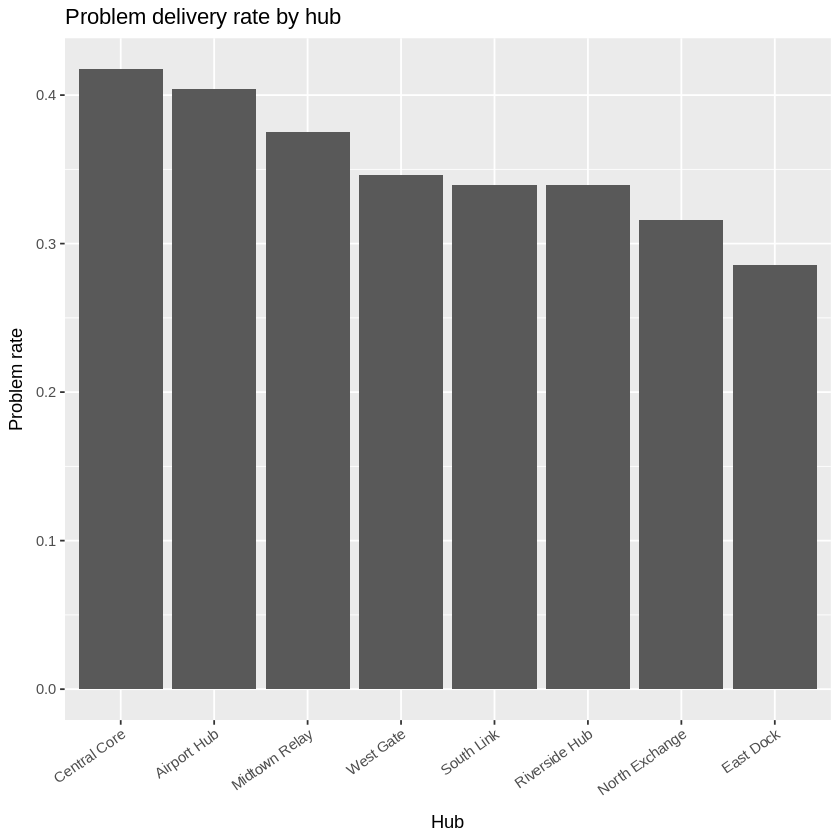

In [7]:
ggplot(hub_sql, aes(x=reorder(hub_name, -problem_rate), y=problem_rate)) +
  geom_col() +
  labs(title="Problem delivery rate by hub", x="Hub", y="Problem rate") +
  theme(axis.text.x = element_text(angle=35, hjust=1))

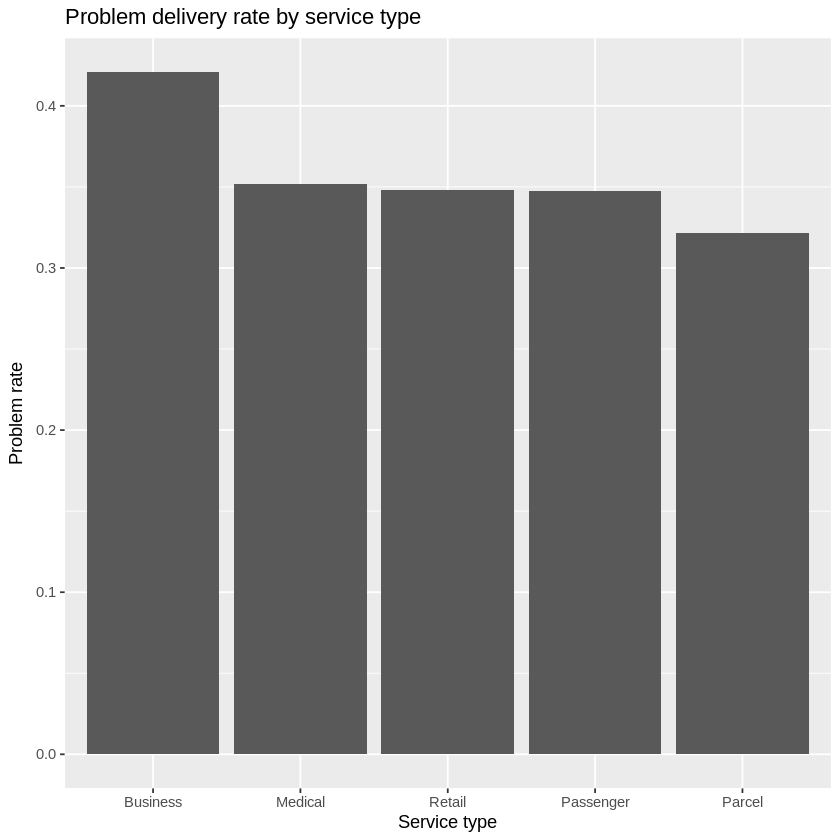

In [8]:
ggplot(service_sql, aes(x=reorder(service_type, -problem_rate), y=problem_rate)) +
  geom_col() +
  labs(title="Problem delivery rate by service type", x="Service type", y="Problem rate")